<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_v8.0/ARIA_v8_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ARIA v8.0 - The Classification Engine
**Course:** NTU Remote Sensing & Spatial Information Analysis (遙測與空間資訊之分析與應用)  
**Instructor:** Prof. Su Wen-Ray  
**Assignment:** Week 12 Homework  
**Due Date:** See NTUCool (typically 1 week after class)  
**Case Study:** Post-Earthquake Land Cover Classification — Xiulin / Taroko Study Area（秀林 / 太魯閣研究區）

---

## Overview

本週你要將 ARIA 系統從 v7.0 升級到 **v8.0 — The Classification Engine**。v7.0 用的是 pixel-level 的閾值（NDVI > T、VV < T_dB）；v8.0 引入分類器，從「一次一個指標分兩類」升級到「同時用所有波段分多類」。

**升級邏輯：**
```
v5.0 (W8)  → 光譜判讀：哪裡有異常？（目視 + 假彩色）
v6.0 (W9)  → 變遷偵測：變了多少？可信嗎？（ΔNDVI + confusion matrix）
v7.0 (W10) → SAR 融合：雲下面發生了什麼？（多源閾值 + 確信度）
v8.0 (W12) → 影像分類：每個像素是什麼地物？（K-means + Random Forest）⬆
```

**Key Deliverable:** A Colab/Jupyter notebook (.ipynb) that demonstrates:
- STAC API 串流 Sentinel-2 多光譜影像（延續 W8–W10 工作流）
- K-means 非監督式分類 → 地物分群
- Random Forest 監督式分類 → 地物類別圖
- Confusion matrix 分類精度評估（呼應 W9）
- AI-generated classification report

###環境設定
> STAC API介接、研究區域設定

In [ ]:
# =============================================================================
# [S1] 環境設定 + STAC API 連線 + 研究區域定義 【COMPLETE — 直接執行】
# =============================================================================
!pip -q install pystac-client planetary-computer stackstac geopandas rasterio scikit-learn matplotlib
from google.colab import drive
drive.mount('/content/drive')
import os, time, warnings
warnings.filterwarnings('ignore')
import logging
import warnings

# 1. 隱藏 rasterio._env 產生的底層 GDAL 警告 (針對你遇到的 CPLE_NotSupported)
logging.getLogger("rasterio").setLevel(logging.ERROR)
logging.getLogger("rasterio._env").setLevel(logging.ERROR)

# 2. (選用) 順便隱藏可能出現的 UserWarning 雜訊
warnings.filterwarnings("ignore", category=UserWarning, module="stackstac")
warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")
# --- 基本套件 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# --- 中文字型設定（跨平台：Colab / Windows / macOS 皆適用）---
# ──下載並強制掛載中文字型 (最穩定解法) ──
import urllib.request
import matplotlib.font_manager as fm
import seaborn as sns
font_path = "NotoSansTC.otf"
font_url = "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=prop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號
sns.set_palette("husl")

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
try:
    import subprocess
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"],
                   capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
except FileNotFoundError:
    pass  # 非 Linux（Windows / macOS），跳過 apt-get
_cjk_candidates = [
    "Microsoft JhengHei",      # Windows 正黑體
    "PingFang TC",             # macOS 蘋方
    "Noto Sans CJK TC",       # Colab / Linux
    "Heiti TC",                # macOS 黑體
    "WenQuanYi Micro Hei",    # Linux
    "Droid Sans Fallback",    # Android / 舊 Linux
]
_available = {f.name for f in fm.fontManager.ttflist}
_cjk_found = [f for f in _cjk_candidates if f in _available]
if _cjk_found:
    plt.rcParams["font.sans-serif"] = _cjk_found + ["DejaVu Sans"]
    print(f"中文字型: {_cjk_found[0]}")
else:
    print("⚠️ 未找到中文字型，中文標題可能顯示為方框")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# --- STAC / 遙測資料載入 ---
import pystac_client
import planetary_computer
import stackstac

# --- 機器學習 ---
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
)
from sklearn.model_selection import train_test_split

# --- 影像後處理 ---
from scipy.ndimage import median_filter

# --- GIS / 向量處理（ROI 多邊形 → 像素遮罩）---
import geopandas as gpd
from shapely.geometry import Polygon
from rasterio.features import rasterize
from rasterio.transform import Affine
import pyproj
import zipfile, xml.etree.ElementTree as ET  # KMZ 解析用

print("所有套件載入成功！")

# --- 連線 Planetary Computer STAC API ---
catalog = pystac_client.Client.open(
  #"https://earth-search.aws.element84.com/v1"
  "https://planetarycomputer.microsoft.com/api/stac/v1",
  modifier=planetary_computer.sign_inplace,
)
print("STAC API 連線成功:", catalog.title)

# Xiulin / Taroko study area BBOX
# West: Central Mountain Range foothills; East: Pacific Ocean (ensures water samples)
TAROKO_BBOX = [121.40, 24.10, 121.80, 24.25]

print(f"研究區域 BBOX: {TAROKO_BBOX}")
print(f"經度範圍: {TAROKO_BBOX[0]:.4f} ~ {TAROKO_BBOX[2]:.4f}")
print(f"緯度範圍: {TAROKO_BBOX[1]:.4f} ~ {TAROKO_BBOX[3]:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 577.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 2.9 MB/s eta 0:00:00
Mounted at /content/drive
中文字型: Noto Sans CJK TC
所有套件載入成功！
STAC API 連線成功: Microsoft Planetary Computer STAC API
研究區域 BBOX: [121.4, 24.1, 121.8, 24.25]
經度範圍: 121.4000 ~ 121.8000
緯度範圍: 24.1000 ~ 24.2500


###註: 因STAC API問題，將max_cc統一為30


In [ ]:
# Post-earthquake imagery — progressive search (strict → relaxed)
# Hualien April-May = plum rain season → high cloud cover, need flexible strategy
search_configs = [
    ('2024-04-15/2024-05-31', 20, 'Phase 1: 2 months post-quake, CC < 20%'),
    ('2024-04-03/2024-08-31', 30, 'Phase 2: 5 months post-quake, CC < 30%'),
    ('2024-04-03/2024-12-31', 50, 'Phase 3: full year post-quake, CC < 50%'),
]

for dt_range, max_cc, desc in search_configs:
    print(f"Trying {desc}...")
    search = catalog.search(
        collections=['sentinel-2-l2a'],
        bbox=TAROKO_BBOX,
        datetime=dt_range,
        query={'eo:cloud_cover': {'lt': 30}},
    )
    items = list(search.items())
    print(f"  → Found {len(items)} scenes")
    if len(items) > 0:
        break

# Sort by cloud cover, pick the best scene
items_sorted = sorted(items, key=lambda x: x.properties['eo:cloud_cover'])
best_item = items_sorted[0]
print(f"Selected: {best_item.id}, cloud cover: {best_item.properties['eo:cloud_cover']:.1f}%")

Trying Phase 1: 2 months post-quake, CC < 20%...
  → Found 0 scenes
Trying Phase 2: 5 months post-quake, CC < 30%...
  → Found 10 scenes
Selected: S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853, cloud cover: 8.4%


### Classification Bands + SCL Cloud Mask

> **Important:** Post-earthquake imagery may have high cloud cover. You **must** apply SCL cloud masking to filter cloud, cloud shadow, and snow pixels before classification. Refer to the in-class Demo cell D3 for implementation details.

### Target Land Cover Classes

| 類別 ID | 名稱 | 英文 | 光譜特徵 |
|---------|------|------|---------|
| 1 | 水體 | Water | NIR 低、SWIR 低 |
| 2 | 森林 | Forest | NIR 高、Red 低 |
| 3 | 農田 | Cropland | NIR 中高、季節變化大 |
| 4 | 裸地/崩塌 | Bare/Landslide | 各波段中等、SWIR 高 |
| 5 | 建物/都市 | Built-up | 反射率高、各波段混合 |

In [ ]:
# 6 reflectance bands + SCL (Scene Classification Layer) for cloud masking
BANDS_ALL = ["B02", "B03", "B04", "B08", "B11", "B12", "SCL"]
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]  # 分類用的 6 波段
BAND_NAMES = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

# 簽章（取得存取憑證）
signed_item = planetary_computer.sign(best_item)

# 使用 stackstac 堆疊（解析度統一為 20m）
# epsg=32651 = UTM 51N（台灣東岸），resolution 單位為公尺
stack = stackstac.stack(
    [signed_item],
    assets=BANDS_ALL,
    epsg=32651,
    resolution=20,
    # 💡 如果有問題可以註解掉 bounds_latlon，讓套件自動讀取影像原始邊界，避免出錯
    bounds_latlon=TAROKO_BBOX,
    dtype="float64",
)

print(f"Lazy 陣列形狀: {stack.shape}  (time, band, y, x)")
print("正在載入資料（.compute()），請稍候...")

# 實際載入資料
data = stack.compute()
img_all = data.values[0]  # shape: (7, H, W)

# --- 分離 SCL 與反射率波段 ---
scl = img_all[-1]           # 最後一個波段 = SCL
img = img_all[:-1] / 10000.0  # 前 6 波段轉為反射率(原先得到的是dN值)

# --- SCL 雲遮罩 ---
# SCL 值定義（Sentinel-2 L2A）：
#   3 = Cloud Shadow, 8 = Cloud (medium prob), 9 = Cloud (high prob), 10 = Cirrus
cloud_mask = np.isin(scl, [3, 8, 9, 10])
n_cloud = int(np.sum(cloud_mask))
n_total = cloud_mask.size
print(f"\n=== SCL 雲遮罩 ===")
print(f"  雲/雲影像素: {n_cloud:,} / {n_total:,} ({n_cloud/n_total*100:.1f}%)")

# 套用雲遮罩（雲像素設為 NaN）
img[:, cloud_mask] = np.nan

# 將其他無效值（<= 0 或 > 1）也設為 NaN
img = np.where((img <= 0) | (img > 1), np.nan, img)

n_bands, n_rows, n_cols = img.shape

print(f"\n影像形狀: {img.shape}  (bands, height, width)")
print(f"像素大小: 20m x 20m")
print(f"影像尺寸: {n_cols * 20 / 1000:.1f} km x {n_rows * 20 / 1000:.1f} km")
print(f"有效像素比例（去雲後）: {np.sum(~np.isnan(img[0])) / img[0].size * 100:.1f}%")

for i, name in enumerate(BAND_NAMES):
    valid = img[i][~np.isnan(img[i])]
    if len(valid) > 0:
        print(
            f"  {name:6s} ({BANDS[i]}): "
            f"min={valid.min():.4f}, max={valid.max():.4f}, mean={valid.mean():.4f}"
        )

# 保存 UTM 座標資訊（後續 ROI 多邊形轉像素用）
x_coords = data.x.values
y_coords = data.y.values
x_res = float(x_coords[1] - x_coords[0])
y_res = float(y_coords[1] - y_coords[0])
img_transform = Affine(x_res, 0, float(x_coords[0]) - x_res/2,
                       0, y_res, float(y_coords[0]) - y_res/2)
print(f"\nUTM Transform 已建立（供 ROI 多邊形柵格化使用）")

Lazy 陣列形狀: (1, 7, 852, 2041)  (time, band, y, x)
正在載入資料（.compute()），請稍候...

=== SCL 雲遮罩 ===
  雲/雲影像素: 145,051 / 1,738,932 (8.3%)

影像形狀: (6, 852, 2041)  (bands, height, width)
像素大小: 20m x 20m
影像尺寸: 40.8 km x 17.0 km
有效像素比例（去雲後）: 91.7%
  Blue   (B02): min=0.0948, max=0.9848, mean=0.1611
  Green  (B03): min=0.0905, max=0.9912, mean=0.1750
  Red    (B04): min=0.0977, max=0.9944, mean=0.1572
  NIR    (B08): min=0.1072, max=0.9968, mean=0.3543
  SWIR1  (B11): min=0.1166, max=0.9927, mean=0.2552
  SWIR2  (B12): min=0.1079, max=0.9949, mean=0.1859

UTM Transform 已建立（供 ROI 多邊形柵格化使用）


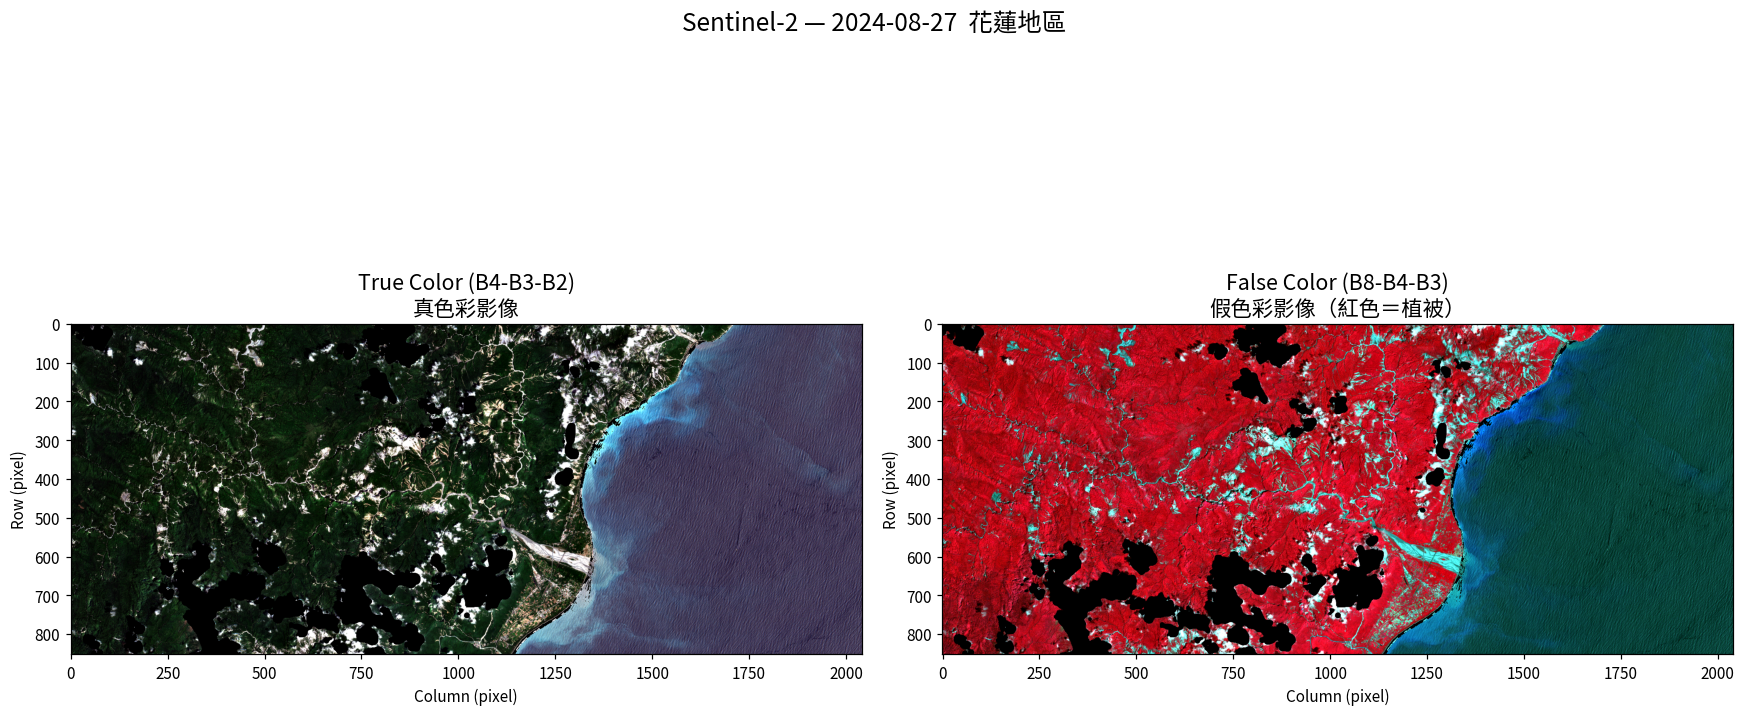

In [ ]:
# =============================================================================
# [S4] RGB 真色彩 + 假色彩視覺化
# =============================================================================

def percentile_stretch(band, low=2, high=98):
    """百分位拉伸：增強影像對比度"""#拉伸 去除最大最小值
    valid = band[~np.isnan(band)]
    if len(valid) == 0:
        return band
    vmin = np.percentile(valid, low)
    vmax = np.percentile(valid, high)
    stretched = (band - vmin) / (vmax - vmin + 1e-10)
    return np.clip(stretched, 0, 1)


def make_rgb(img_array, band_indices, low=2, high=98):
    """組合 RGB 影像並做百分位拉伸"""
    rgb = np.stack(
        [percentile_stretch(img_array[i], low, high) for i in band_indices],
        axis=-1,
    )
    return np.nan_to_num(rgb, nan=0)


# 波段索引: B02=0(Blue), B03=1(Green), B04=2(Red),
#           B08=3(NIR),  B11=4(SWIR1), B12=5(SWIR2)
true_color = make_rgb(img, [2, 1, 0])    # R=B04, G=B03, B=B02
false_color = make_rgb(img, [3, 2, 1])   # R=B08, G=B04, B=B03

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(true_color)
axes[0].set_title("True Color (B4-B3-B2)\n真色彩影像", fontsize=14)
axes[0].set_xlabel("Column (pixel)")
axes[0].set_ylabel("Row (pixel)")

axes[1].imshow(false_color)
axes[1].set_title(
    "False Color (B8-B4-B3)\n假色彩影像（紅色＝植被）", fontsize=14
)
axes[1].set_xlabel("Column (pixel)")
axes[1].set_ylabel("Row (pixel)")

plt.suptitle(
    f"Sentinel-2 — {best_item.datetime.strftime('%Y-%m-%d')}  花蓮地區",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

### Task 1: K-means Unsupervised Classification (15%)

**Goal:** Apply K-means to the post-earthquake multispectral image to explore spectral clustering without training data.

In [ ]:
# =============================================================================
# Task 1.1: 建立特徵矩陣 (Feature Matrix)
# =============================================================================

# 從 Pre-lab 我們已經取得 img (shape: 6, n_rows, n_cols)
# 將 3D 影像攤平為 2D 矩陣 (n_pixels, n_bands)
X = img.reshape(n_bands, -1).T  # shape: (n_rows * n_cols, 6)

# 找出沒有 NaN 的有效像素
valid = ~np.isnan(X).any(axis=1)

# 只保留有效的像素來進行分類
X_valid = X[valid]

print(f"整張影像總像素: {X.shape[0]:,}")
print(f"去除雲/無效值後的特徵矩陣 (X_valid): {X_valid.shape}")

整張影像總像素: 1,738,932
去除雲/無效值後的特徵矩陣 (X_valid): (1593823, 6)


### 執行 K-means 分群

利用 `scikit-learn` 套件執行 K-means，設定群數 `K=5`（對應我們的 5 種地物類別：水體、森林、農田、裸地/崩塌、建物/都市）。
**注意：** 如果你的研究區範圍較大，這一步可能會跑 1~3 分鐘。

總像素數    : 1,738,932
有效像素數  : 1,593,823
特徵維度    : 6 波段

正在執行 K-means (K=5)...
K-means 完成！ Inertia = 8175.73


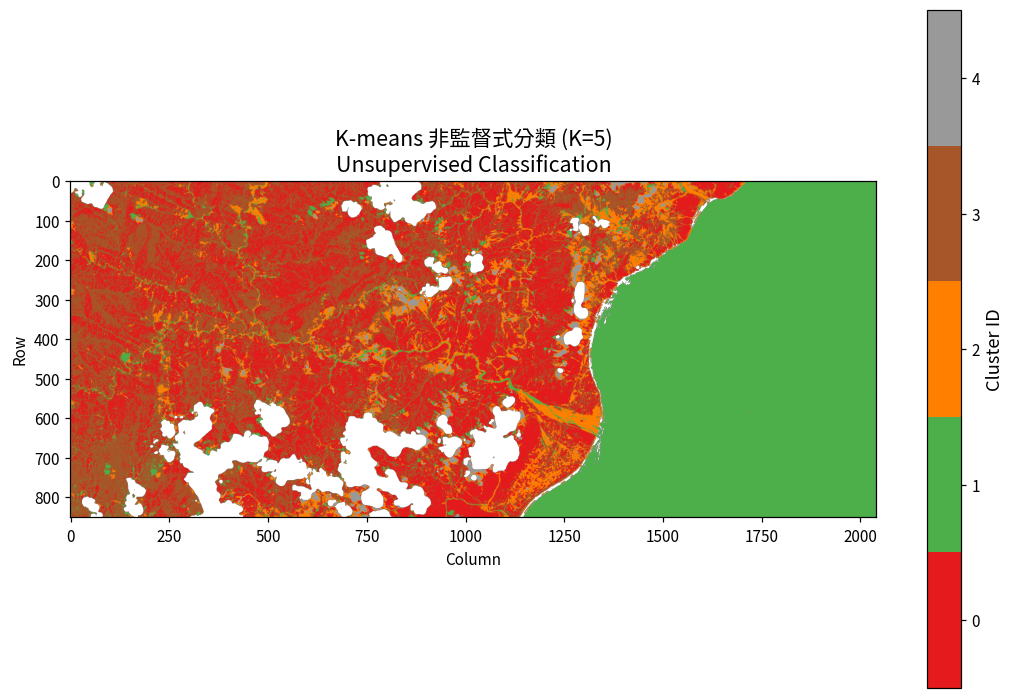


各群組像素統計:
  Cluster 0:  445,400 pixels (27.9%)
  Cluster 1:  584,806 pixels (36.7%)
  Cluster 2:  108,071 pixels (6.8%)
  Cluster 3:  434,863 pixels (27.3%)
  Cluster 4:   20,683 pixels (1.3%)


In [ ]:
# =============================================================================
# Task 1.2: K-means 分群與視覺化
# ============================================================================

# --- 建立特徵矩陣（已預先填好）---
# 重塑為 (n_pixels, n_bands)
pixels = img.reshape(n_bands, -1).T  # shape: (n_pixels, 6)

# 找出有效像素（所有波段皆非 NaN）
valid_pixel_mask = ~np.any(np.isnan(pixels), axis=1)
pixels_valid = pixels[valid_pixel_mask]

print(f"總像素數    : {pixels.shape[0]:,}")
print(f"有效像素數  : {pixels_valid.shape[0]:,}")
print(f"特徵維度    : {pixels_valid.shape[1]} 波段")

# ── YOUR TURN ──
# 1. 建立 KMeans 模型並進行分類
# Hint: KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
K = 5
print(f"\n正在執行 K-means (K={K})...")

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)  # 建立 KMeans 物件
labels_km = kmeans.fit_predict(pixels_valid)  # 使用 fit_predict() 對 pixels_valid 進行分類

print(f"K-means 完成！ Inertia = {kmeans.inertia_:.2f}")
# ── END YOUR TURN ──

# --- 重建分類圖（已預先填好）---
class_map_km = np.full(pixels.shape[0], np.nan)
class_map_km[valid_pixel_mask] = labels_km
class_map_km = class_map_km.reshape(n_rows, n_cols)

# ── YOUR TURN ──
# 2. 視覺化分類結果
# Hint: 使用 ax.imshow() 顯示 class_map_km
# Hint: 使用 plt.cm.get_cmap("Set1", K) 作為色彩映射
fig, ax = plt.subplots(figsize=(10, 8))
cmap_km = plt.cm.get_cmap("Set1", K)

im = ax.imshow(class_map_km, cmap=cmap_km, vmin=-0.5, vmax=K - 0.5)  # 填入正確的資料和色彩映射

cbar = plt.colorbar(im, ax=ax, ticks=range(K), shrink=0.8)
cbar.set_label("Cluster ID", fontsize=12)
ax.set_title(
    f"K-means 非監督式分類 (K={K})\nUnsupervised Classification", fontsize=14
)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.show()
# ── END YOUR TURN ──

# 統計各群組像素數
print("\n各群組像素統計:")
for c in range(K):
    count = np.sum(labels_km == c)
    print(f"  Cluster {c}: {count:>8,} pixels ({count / len(labels_km) * 100:.1f}%)")

### 萃取群集光譜特徵 (Cluster Spectral Analysis)

非監督式分類雖然分出了 5 群，但我們不知道哪一群代表什麼地物。這一步我們要計算每個群集在各波段的平均反射率，以利後續透過光譜特徵（如 NDVI, SWIR 反射率等）來手動定義這 5 群的真實類別。

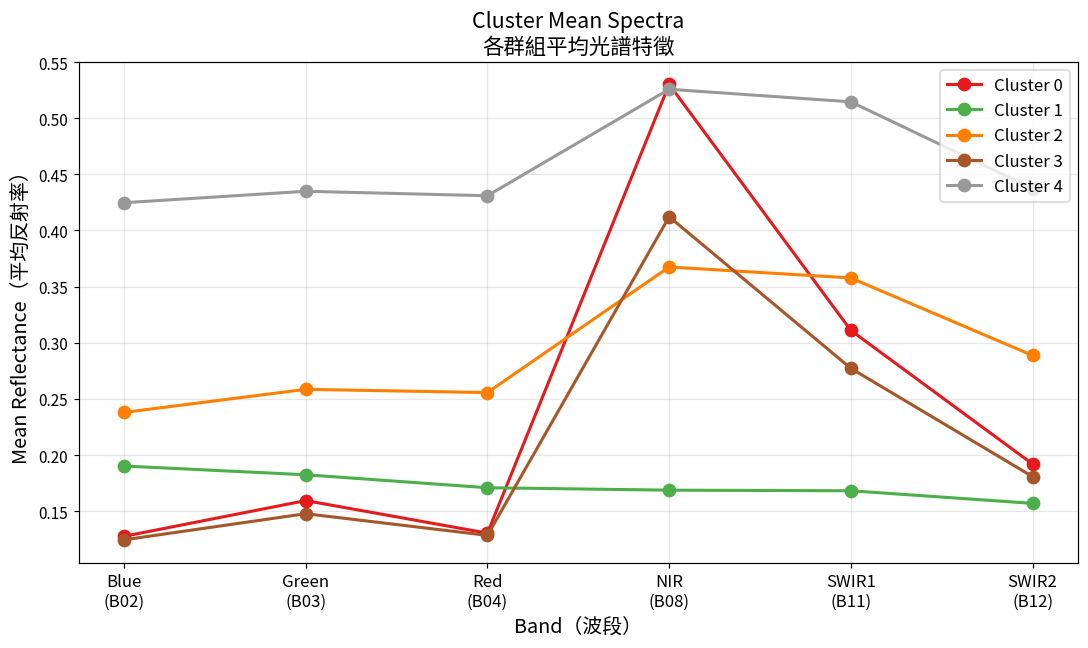


=== 光譜特徵判讀指引（檢查你的結果是否合理）===
  - NIR 高、Red 低 → 健康植被
  - 所有波段都低   → 水體
  - Red/SWIR 高    → 裸地 / 崩塌地
  - 整體偏亮       → 建物 / 人造地物

提示：如果你的圖中有一條曲線在 NIR 處有明顯高峰，那很可能是植被 cluster。


In [ ]:
# =============================================================================
# Task 1.3: 計算各群集平均光譜
# =============================================================================

# 繪圖設定
fig, ax = plt.subplots(figsize=(10, 6))
colors_spec = plt.cm.Set1(np.linspace(0, 1, K))

# ── YOUR TURN ──
# 計算每個 cluster 的平均反射率，並繪製光譜曲線
# Hint: 對每個 cluster c (0 到 K-1)：
#   1. 用 pixels_valid[labels_km == c] 取出該 cluster 的像素
#   2. 用 .mean(axis=0) 計算平均光譜
#   3. 用 ax.plot() 繪製折線圖

cluster_means = np.zeros((K, n_bands))

for c in range(K):
    # 計算第 c 個 cluster 的平均反射率
    cluster_means[c] = pixels_valid[labels_km == c].mean(axis=0)  # Hint: pixels_valid[labels_km == c].mean(axis=0)

    # 繪製該 cluster 的光譜曲線
    ax.plot(
        range(n_bands),
        cluster_means[c],  # Hint: cluster_means[c]
        "o-",
        color=colors_spec[c],
        linewidth=2,
        markersize=8,
        label=f"Cluster {c}",
    )
# ── END YOUR TURN ──

ax.set_xticks(range(n_bands))
ax.set_xticklabels(
    [f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in range(n_bands)], fontsize=11
)
ax.set_ylabel("Mean Reflectance（平均反射率）", fontsize=13)
ax.set_xlabel("Band（波段）", fontsize=13)
ax.set_title("Cluster Mean Spectra\n各群組平均光譜特徵", fontsize=14)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 答案驗證：預期光譜模式
print("\n=== 光譜特徵判讀指引（檢查你的結果是否合理）===")
print("  - NIR 高、Red 低 → 健康植被")
print("  - 所有波段都低   → 水體")
print("  - Red/SWIR 高    → 裸地 / 崩塌地")
print("  - 整體偏亮       → 建物 / 人造地物")
print("\n提示：如果你的圖中有一條曲線在 NIR 處有明顯高峰，那很可能是植被 cluster。")

手動將Cluster對應到正確分類

In [ ]:
# =============================================================================
# Task 1.4: 手動標記Cluster類型
# =============================================================================
# 建立 K-means 群集與地物類別的手動對應字典
# 格式: {Cluster_ID: 'Land Cover Class'}
kmeans_class_mapping = {
    0: 'Forest (森林)',
    1: 'Water (水體)',
    2: 'Bare/Landslide (裸地/崩塌)',
    3: 'Cropland (農田)',
    4: 'Built-up (建物/都市)'
}

print("Task 1 手動標籤對應完成：")
for k, v in kmeans_class_mapping.items():
    print(f"Cluster {k} -> {v}")

Task 1 手動標籤對應完成：
Cluster 0 -> Forest (森林)
Cluster 1 -> Water (水體)
Cluster 2 -> Bare/Landslide (裸地/崩塌)
Cluster 3 -> Cropland (農田)
Cluster 4 -> Built-up (建物/都市)


###Brief discussion: which clusters are easy/hard to interpret? Why?
  Ans: 最易於分辨的是Cluster 0(森林)、Cluster 1(水體)。前者在NIR明顯上升，後者則全部波段都低。其他三者Cluster 2、Cluster 4有類似的波型，前者高後者尤高，所以推測分別是裸地以及建物或其他高反射物。但Cluster 3則難確認，因為他波型類似Cluster 0，但在地圖上可以發現除了真實農田的區域、山上較稀疏的區域也被歸類到此Cluster，造成異物同譜的現象。

### Task 2: Random Forest Supervised Classification (25%)

**Goal:** Apply Random Forest supervised classification to produce a land cover map with labeled classes.


請上傳你在 Google Earth 製作的 KMZ 檔案...


Saving TAROKO_TRAINING_DATA.kmz to TAROKO_TRAINING_DATA.kmz
已上傳: TAROKO_TRAINING_DATA.kmz

--- 解析 KMZ ---
  ✓ 水體 → Water
  ✓ 水體 → Water
  ✓ 水體 → Water
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 裸露地 → Bare/Landslide
  ✓ 森林 → Forest
  ✓ 農田 → Agriculture
  ✓ 農田 → Agriculture
  ✓ 農田 → Agriculture
  ✓ 農田 → Agriculture
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 裸露地 → Bare/Landslide
  ✓ 農田 → Agriculture
  ✓ 建物 → Built-up

=== 訓練樣本統計 ===
總訓練像素數: 53,801

  Class 0 (           Water / 水體): 30,651 pixels, 3 個多邊形  ✅
  Class 1 (          Forest / 森林): 16,252 pixels, 6 個多邊形  ✅
  Class 2 (     Agriculture / 農地):  2,494 pixels, 5 個多邊形  ✅
  Class 3 (  Bare/Landslide / 裸地/崩塌):  4,205 pixe

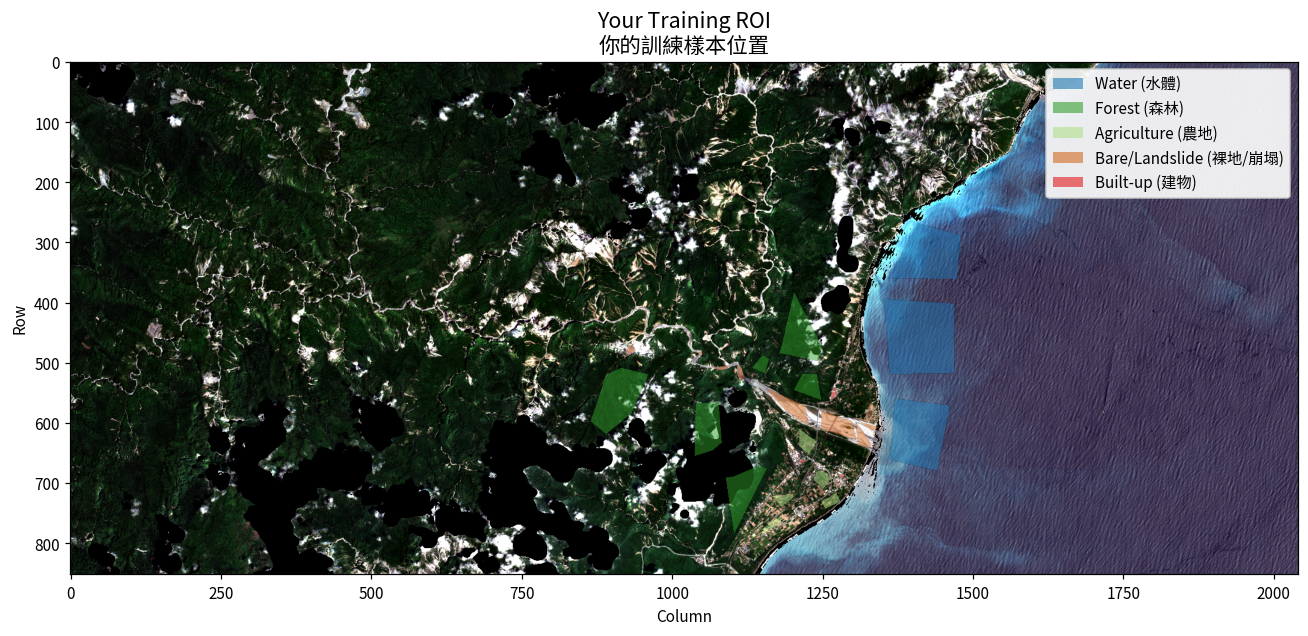


檢查你的 ROI 是否合理：
  - 水體 ROI 是否確實在海面或河流上？
  - 森林 ROI 是否在山坡密林區？
  - 每類是否至少有 30+ 像素？


In [ ]:
# =============================================================================
# Task 2.1: Using Method B KMZ training data
# =============================================================================
# 步驟：
#   1. 在 Google Earth Pro 繪製多邊形 ROI（見上方說明）
#   2. 匯出為 KMZ 檔案
#   3. 執行此 cell，會跳出上傳對話框
#   4. 程式自動解析多邊形 → 轉 UTM → 柵格化 → 提取訓練像素

from google.colab import files

# --- 類別定義 ---
CLASS_NAMES = ["Water", "Forest", "Agriculture", "Bare/Landslide", "Built-up"]
CLASS_NAMES_ZH = ["水體", "森林", "農地", "裸地/崩塌", "建物"]
N_CLASSES = len(CLASS_NAMES)

# KMZ 中的多邊形名稱 → 類別 ID 對照表
# （你在 Google Earth 裡的多邊形名稱必須包含以下關鍵字之一）
name_to_class = {
    "水體": 0, "水": 0, "Water": 0, "water": 0,
    "森林": 1, "林": 1, "Forest": 1, "forest": 1,
    "農地": 2, "農": 2, "Agriculture": 2, "agriculture": 2, "Cropland": 2,
    "裸露地": 3, "裸地": 3, "崩塌": 3, "裸": 3, "Bare": 3, "bare": 3, "Landslide": 3,
    "建物": 4, "建": 4, "Built": 4, "built": 4, "Built-up": 4,
}

# ── YOUR TURN ──
# 上傳你的 KMZ 檔案（執行此 cell 會出現上傳按鈕）
print("請上傳你在 Google Earth 製作的 KMZ 檔案...")
uploaded = files.upload()
kmz_filename = list(uploaded.keys())[0]
print(f"已上傳: {kmz_filename}")
# ── END YOUR TURN ──

# --- 解析 KMZ（自動處理，不需修改）---
def parse_kmz(filename):
    """解析 KMZ 檔案，回傳 {class_id: [Polygon, ...]} 字典"""
    ns = {"kml": "http://www.opengis.net/kml/2.2"}
    polygons_by_class = {i: [] for i in range(N_CLASSES)}

    with zipfile.ZipFile(filename, 'r') as z:
        kml_name = [n for n in z.namelist() if n.endswith('.kml')][0]
        with z.open(kml_name) as f:
            tree = ET.parse(f)

    for pm in tree.findall(".//{http://www.opengis.net/kml/2.2}Placemark"):
        name_elem = pm.find("{http://www.opengis.net/kml/2.2}name")
        coords_elem = pm.find(".//{http://www.opengis.net/kml/2.2}coordinates")
        if name_elem is None or coords_elem is None:
            continue

        # 比對名稱 → 類別 ID
        pm_name = name_elem.text.strip()
        cls_id = None
        for keyword, cid in name_to_class.items():
            if keyword in pm_name:
                cls_id = cid
                break
        if cls_id is None:
            print(f"  ⚠️ 無法辨識類別: '{pm_name}'，已跳過")
            continue

        # 解析座標
        coords_text = coords_elem.text.strip()
        points = []
        for c in coords_text.split():
            parts = c.split(",")
            points.append((float(parts[0]), float(parts[1])))

        if len(points) >= 3:
            poly = Polygon(points)
            if poly.is_valid and poly.area > 0:
                polygons_by_class[cls_id].append(poly)
                print(f"  ✓ {pm_name} → {CLASS_NAMES[cls_id]}")

    return polygons_by_class

print("\n--- 解析 KMZ ---")
polygons_by_class = parse_kmz(kmz_filename)

# --- 轉 UTM + 柵格化（自動處理）---
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)
shapes_for_rasterize = []

for cls_id, poly_list in polygons_by_class.items():
    for poly in poly_list:
        coords_utm = [transformer.transform(x, y) for x, y in poly.exterior.coords]
        poly_utm = Polygon(coords_utm)
        if poly_utm.is_valid and poly_utm.area > 0:
            shapes_for_rasterize.append((poly_utm, cls_id))

roi_raster = rasterize(
    shapes_for_rasterize,
    out_shape=(n_rows, n_cols),
    transform=img_transform,
    fill=-1,
    dtype=np.int8,
    all_touched=True,
)

# --- 提取訓練像素 ---
X_train_list = []
y_train_list = []

for cls_id in range(N_CLASSES):
    cls_mask = (roi_raster == cls_id)
    cls_pixels = img[:, cls_mask].T
    valid_rows = ~np.any(np.isnan(cls_pixels), axis=1)
    cls_valid = cls_pixels[valid_rows]
    if len(cls_valid) > 0:
        X_train_list.append(cls_valid)
        y_train_list.append(np.full(len(cls_valid), cls_id))

X_roi = np.vstack(X_train_list)
y_roi = np.concatenate(y_train_list)

# --- 統計報告 ---
print("\n=== 訓練樣本統計 ===")
print(f"總訓練像素數: {len(y_roi):,}\n")
for cls_id in range(N_CLASSES):
    count = int(np.sum(y_roi == cls_id))
    n_poly = len(polygons_by_class[cls_id])
    status = "✅" if count >= 30 else "⚠️ 偏少，建議增加 ROI"
    print(
        f"  Class {cls_id} ({CLASS_NAMES[cls_id]:>16s} / "
        f"{CLASS_NAMES_ZH[cls_id]}): {count:>6,} pixels, "
        f"{n_poly} 個多邊形  {status}"
    )

# --- 視覺化 ROI ---
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(make_rgb(img, [2, 1, 0]))

roi_colors_vis = ["#1f78b4", "#33a02c", "#b2df8a", "#d2691e", "#e31a1c"]
for cls_id in range(N_CLASSES):
    mask = (roi_raster == cls_id)
    if np.any(mask):
        overlay = np.zeros((*mask.shape, 4))
        c = mcolors.to_rgba(roi_colors_vis[cls_id], alpha=0.5)
        overlay[mask] = c
        ax.imshow(overlay)

legend_roi = [Patch(facecolor=roi_colors_vis[i], alpha=0.6,
                    label=f"{CLASS_NAMES[i]} ({CLASS_NAMES_ZH[i]})")
              for i in range(N_CLASSES)]
ax.legend(handles=legend_roi, loc="upper right", fontsize=10, framealpha=0.9)
ax.set_title("Your Training ROI\n你的訓練樣本位置", fontsize=14)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.show()

print("\n檢查你的 ROI 是否合理：")
print("  - 水體 ROI 是否確實在海面或河流上？")
print("  - 森林 ROI 是否在山坡密林區？")
print("  - 每類是否至少有 30+ 像素？")

📊  檢查 1／4：樣本數量
             Water (水體): 30,651 pixels  ✅ 充足
            Forest (森林): 16,252 pixels  ✅ 充足
       Agriculture (農地):  2,494 pixels  ✅ 充足
    Bare/Landslide (裸地/崩塌):  4,205 pixels  ✅ 充足
          Built-up (建物):    199 pixels  ✅ 合格

🌈  檢查 2／4：光譜合理性（各類別光譜是否符合物理預期）

  Water (水體):
    平均光譜: Blue=0.2099 Green=0.1990 Red=0.1756 NIR=0.1666 SWIR1=0.1655 SWIR2=0.1559
    NDVI=-0.026
    ⚠️ NIR 應低（< 0.10） — 未通過
       💡 水體強烈吸收近紅外光，NIR 反射率應很低。你的水體 ROI 可能包含了陸地像素。
    ⚠️ SWIR 應低（< 0.08） — 未通過
       💡 水體在 SWIR 波段幾乎完全吸收。如果偏高，可能選到了淺水區或河岸。
    ✅ Blue > NIR

  Forest (森林):
    平均光譜: Blue=0.1430 Green=0.1687 Red=0.1425 NIR=0.5081 SWIR1=0.3113 SWIR2=0.1994
    NDVI=0.562
    ✅ NDVI 應高（> 0.4）
    ✅ NIR 應高（> 0.15）
    ⚠️ Red 應低（< 0.10） — 未通過
       💡 森林強烈吸收紅光用於光合作用。Red 偏高可能選到了枯萎或裸露區。

  Agriculture (農地):
    平均光譜: Blue=0.1564 Green=0.1914 Red=0.1795 NIR=0.4363 SWIR1=0.3475 SWIR2=0.2591
    NDVI=0.417
    ✅ NDVI 應為正（> 0.2）
    ✅ NIR 應適中
    → 光譜特徵合理 👍

  Bare/Landslide (裸地/崩塌):
    平均光譜: Blue=0.

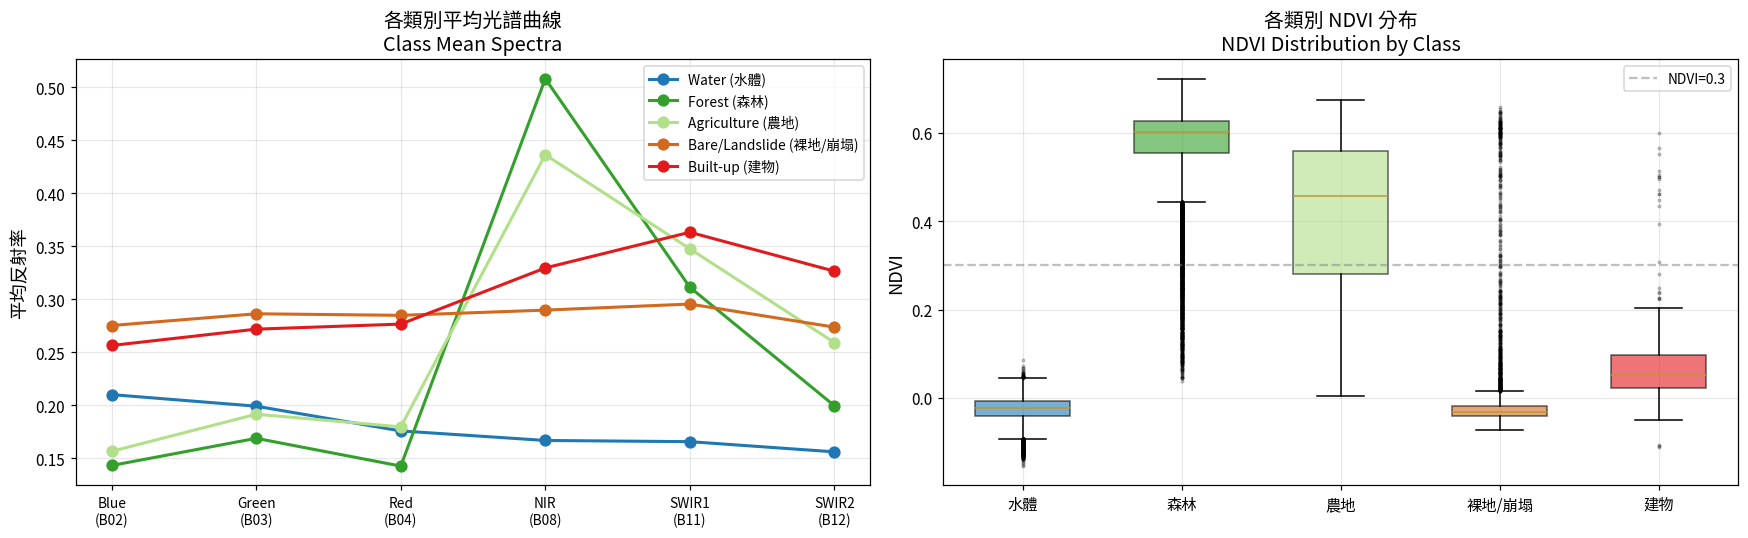


左圖：如果兩條曲線形狀幾乎重疊，表示這兩類容易混淆。
右圖：NDVI 分布應該——水體最低、裸地次低、農地中等、森林最高。


In [ ]:
# =============================================================================
# Task 2.2: ROI 智慧驗證 — 自動診斷訓練樣本品質
# =============================================================================
# 此程式模擬遙測專家的審查流程，自動檢查你的 ROI 是否適合訓練分類模型。
# 不需修改任何程式碼，直接執行即可看到診斷報告。

import textwrap

# ===================== 1. 樣本數量檢查 =====================
print("=" * 70)
print("📊  檢查 1／4：樣本數量")
print("=" * 70)

# Random Forest 經驗法則：每類至少 10 × 特徵數（6 波段 → 60），建議 100+
MIN_PIXELS = 30       # 最低門檻
REC_PIXELS = 100      # 建議值
GOOD_PIXELS = 500     # 理想值

qty_issues = []
for cls_id in range(N_CLASSES):
    count = int(np.sum(y_roi == cls_id))
    if count == 0:
        grade = "❌ 無樣本"
        qty_issues.append((cls_id, "missing"))
    elif count < MIN_PIXELS:
        grade = f"⚠️ 不足（最少 {MIN_PIXELS}）"
        qty_issues.append((cls_id, "low"))
    elif count < REC_PIXELS:
        grade = f"🔶 偏少（建議 {REC_PIXELS}+）"
        qty_issues.append((cls_id, "marginal"))
    elif count < GOOD_PIXELS:
        grade = "✅ 合格"
    else:
        grade = "✅ 充足"
    print(f"  {CLASS_NAMES[cls_id]:>16s} ({CLASS_NAMES_ZH[cls_id]}): "
          f"{count:>6,} pixels  {grade}")

# ===================== 2. 光譜合理性檢查 =====================
print(f"\n{'=' * 70}")
print("🌈  檢查 2／4：光譜合理性（各類別光譜是否符合物理預期）")
print("=" * 70)

# 波段索引: B02=0, B03=1, B04=2(Red), B08=3(NIR), B11=4(SWIR1), B12=5(SWIR2)
spectral_issues = []

# 計算各類別的波段平均值
class_means = {}
for cls_id in range(N_CLASSES):
    mask_cls = (y_roi == cls_id)
    if np.sum(mask_cls) > 0:
        class_means[cls_id] = X_roi[mask_cls].mean(axis=0)
    else:
        class_means[cls_id] = None

# 定義光譜規則（基於遙測物理原理）
spectral_rules = {
    0: [  # Water
        ("NIR 應低（< 0.10）", lambda m: m[3] < 0.10,
         "水體強烈吸收近紅外光，NIR 反射率應很低。你的水體 ROI 可能包含了陸地像素。"),
        ("SWIR 應低（< 0.08）", lambda m: m[4] < 0.08,
         "水體在 SWIR 波段幾乎完全吸收。如果偏高，可能選到了淺水區或河岸。"),
        ("Blue > NIR", lambda m: m[0] > m[3],
         "水體的 Blue 反射率通常高於 NIR。如果不是，可能 ROI 不在水面上。"),
    ],
    1: [  # Forest
        ("NDVI 應高（> 0.4）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) > 0.4,
         "健康森林的 NDVI 通常在 0.5-0.8。偏低可能選到了稀疏植被或混合像素。"),
        ("NIR 應高（> 0.15）", lambda m: m[3] > 0.15,
         "森林的 NIR 反射率應較高（植被結構散射）。"),
        ("Red 應低（< 0.10）", lambda m: m[2] < 0.10,
         "森林強烈吸收紅光用於光合作用。Red 偏高可能選到了枯萎或裸露區。"),
    ],
    2: [  # Agriculture
        ("NDVI 應為正（> 0.2）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) > 0.2,
         "農地（即使休耕）通常有些植被覆蓋。NDVI 太低可能選到了裸露田地。"),
        ("NIR 應適中", lambda m: m[3] > 0.10,
         "農地的 NIR 反射率應至少適中。"),
    ],
    3: [  # Bare/Landslide
        ("NDVI 應低（< 0.3）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) < 0.3,
         "裸露地表幾乎沒有植被，NDVI 應接近 0 或為負。偏高可能選到了植被恢復區。"),
        ("Red 或 SWIR 應可見", lambda m: m[2] > 0.05 or m[4] > 0.05,
         "裸地在可見光和 SWIR 都有一定反射率。"),
    ],
    4: [  # Built-up
        ("NDBI 應為正或接近 0", lambda m: (m[4] - m[3]) / (m[4] + m[3] + 1e-10) > -0.15,
         "建物的 NDBI（SWIR-NIR 差異）通常高於植被。如果太負，可能選到了公園綠地。"),
        ("整體反射率應適中",
         lambda m: np.mean([m[0], m[1], m[2]]) > 0.04,
         "建物（混凝土、鐵皮屋頂）在可見光有一定反射率。太低可能是陰影或水域。"),
    ],
}

for cls_id in range(N_CLASSES):
    m = class_means[cls_id]
    if m is None:
        print(f"\n  {CLASS_NAMES[cls_id]}: ❌ 無樣本，無法檢查")
        continue

    print(f"\n  {CLASS_NAMES[cls_id]} ({CLASS_NAMES_ZH[cls_id]}):")
    ndvi = (m[3] - m[2]) / (m[3] + m[2] + 1e-10)
    print(f"    平均光譜: Blue={m[0]:.4f} Green={m[1]:.4f} Red={m[2]:.4f} "
          f"NIR={m[3]:.4f} SWIR1={m[4]:.4f} SWIR2={m[5]:.4f}")
    print(f"    NDVI={ndvi:.3f}")

    rules = spectral_rules.get(cls_id, [])
    all_pass = True
    for rule_name, check_fn, advice in rules:
        passed = check_fn(m)
        if passed:
            print(f"    ✅ {rule_name}")
        else:
            print(f"    ⚠️ {rule_name} — 未通過")
            print(f"       💡 {advice}")
            spectral_issues.append((cls_id, rule_name))
            all_pass = False
    if all_pass and len(rules) > 0:
        print(f"    → 光譜特徵合理 👍")

# ===================== 3. 類別可分離性分析 =====================
print(f"\n{'=' * 70}")
print("📐  檢查 3／4：類別可分離性（各類之間是否容易區分）")
print("=" * 70)

# 使用簡化版 Jeffries-Matusita 距離
# JM ∈ [0, 2]：> 1.9 優秀，1.5-1.9 良好，< 1.5 需注意
separability_issues = []

def bhattacharyya_distance(X1, X2):
    """計算兩組樣本的 Bhattacharyya 距離（簡化版）"""
    if len(X1) < 2 or len(X2) < 2:
        return 0.0
    m1, m2 = X1.mean(axis=0), X2.mean(axis=0)
    s1, s2 = np.cov(X1.T) + np.eye(X1.shape[1]) * 1e-6, \
             np.cov(X2.T) + np.eye(X2.shape[1]) * 1e-6
    s_avg = (s1 + s2) / 2
    try:
        sign, logdet = np.linalg.slogdet(s_avg)
        sign1, logdet1 = np.linalg.slogdet(s1)
        sign2, logdet2 = np.linalg.slogdet(s2)
        if sign <= 0 or sign1 <= 0 or sign2 <= 0:
            return 0.0
        dm = m1 - m2
        term1 = 0.125 * dm @ np.linalg.solve(s_avg, dm)
        term2 = 0.5 * (logdet - 0.5 * (logdet1 + logdet2))
        bd = term1 + term2
        jm = 2 * (1 - np.exp(-bd))
        return min(jm, 2.0)
    except np.linalg.LinAlgError:
        return 0.0

print(f"\n  {'':20s}", end="")
for j in range(N_CLASSES):
    print(f"{CLASS_NAMES[j][:8]:>10s}", end="")
print()

for i in range(N_CLASSES):
    print(f"  {CLASS_NAMES[i]:20s}", end="")
    for j in range(N_CLASSES):
        if i == j:
            print(f"{'---':>10s}", end="")
        elif j > i:
            Xi = X_roi[y_roi == i]
            Xj = X_roi[y_roi == j]
            if len(Xi) < 2 or len(Xj) < 2:
                print(f"{'N/A':>10s}", end="")
            else:
                jm = bhattacharyya_distance(Xi, Xj)
                if jm >= 1.9:
                    label = f"{jm:.2f} ✅"
                elif jm >= 1.5:
                    label = f"{jm:.2f} 🔶"
                else:
                    label = f"{jm:.2f} ⚠️"
                    separability_issues.append(
                        (CLASS_NAMES[i], CLASS_NAMES[j], jm))
                print(f"{label:>10s}", end="")
        else:
            print(f"{'':>10s}", end="")
    print()

print(f"\n  判讀：JM 距離 > 1.9 = 容易區分，1.5-1.9 = 尚可，< 1.5 = 易混淆")
if separability_issues:
    print(f"\n  ⚠️ 以下類別對容易混淆：")
    for c1, c2, jm in separability_issues:
        print(f"    • {c1} vs {c2} (JM={jm:.2f})")
        print(f"      💡 建議：選擇更典型的 ROI 區域，或考慮合併這兩類")
else:
    print(f"\n  ✅ 所有類別對的可分離性良好")

# ===================== 4. 空間分布檢查 =====================
print(f"\n{'=' * 70}")
print("🗺️  檢查 4／4：ROI 空間分布（是否過度集中）")
print("=" * 70)

spatial_issues = []
img_center_r, img_center_c = n_rows // 2, n_cols // 2
img_diag = np.sqrt(n_rows**2 + n_cols**2)

for cls_id in range(N_CLASSES):
    mask_cls = (roi_raster == cls_id)
    if not np.any(mask_cls):
        continue
    rows_cls, cols_cls = np.where(mask_cls)
    # 計算 ROI 的空間範圍相對於影像大小
    row_span = (rows_cls.max() - rows_cls.min()) / n_rows
    col_span = (cols_cls.max() - cols_cls.min()) / n_cols
    # 如果所有 ROI 像素都集中在影像的一小塊區域
    spread = max(row_span, col_span)
    n_poly = len(polygons_by_class[cls_id])

    if n_poly == 1 and spread < 0.05:
        status = "⚠️ 僅 1 個小區域，空間代表性不足"
        spatial_issues.append((cls_id, "single_small"))
    elif spread < 0.02:
        status = "⚠️ ROI 過度集中"
        spatial_issues.append((cls_id, "concentrated"))
    elif n_poly >= 2:
        status = f"✅ {n_poly} 個多邊形，分布合理"
    else:
        status = "🔶 建議增加更多分散的 ROI"

    print(f"  {CLASS_NAMES[cls_id]:>16s}: 空間範圍 {spread*100:.1f}% 影像寬度, "
          f"{n_poly} 個多邊形  {status}")

# ===================== 綜合評估報告 =====================
print(f"\n{'=' * 70}")
print("📋  綜合評估報告")
print("=" * 70)

total_issues = len(qty_issues) + len(spectral_issues) + \
               len(separability_issues) + len(spatial_issues)

if total_issues == 0:
    print("\n  🎉 你的 ROI 品質優秀！所有檢查項目都通過了。")
    print("     可以放心進入下一步訓練模型。")
elif total_issues <= 3:
    print(f"\n  👍 大致良好，發現 {total_issues} 個小問題：")
else:
    print(f"\n  ⚠️ 發現 {total_issues} 個問題，建議改善後再訓練模型：")

# 具體改善建議
suggestions = []
for cls_id, level in qty_issues:
    if level == "missing":
        suggestions.append(
            f"• {CLASS_NAMES[cls_id]}：完全沒有樣本！請在 Google Earth 中為此類別"
            f"畫至少 2 個多邊形。")
    elif level == "low":
        suggestions.append(
            f"• {CLASS_NAMES[cls_id]}：像素數不足 {MIN_PIXELS}。"
            f"請畫更大的多邊形或增加更多 ROI 區域。")
    elif level == "marginal":
        suggestions.append(
            f"• {CLASS_NAMES[cls_id]}：像素數偏少。"
            f"建議擴大 ROI 面積至 {REC_PIXELS}+ 像素以提高模型穩定性。")

for cls_id, rule_name in spectral_issues:
    suggestions.append(
        f"• {CLASS_NAMES[cls_id]}：光譜檢查「{rule_name}」未通過。"
        f"請確認 ROI 位置是否正確（可對照真色彩影像）。")

for c1, c2, jm in separability_issues:
    suggestions.append(
        f"• {c1} 與 {c2} 光譜相似（JM={jm:.2f}），"
        f"可能導致混淆。嘗試選擇更具代表性的典型區域。")

for cls_id, issue_type in spatial_issues:
    suggestions.append(
        f"• {CLASS_NAMES[cls_id]}：ROI 空間分布過於集中。"
        f"建議在不同位置多畫幾個多邊形，提高空間代表性。")

for s in suggestions:
    print(f"  {s}")

if total_issues > 0:
    print(f"\n  修改 KMZ 後重新執行 [S12] 和此 cell 即可更新診斷。")
else:
    print(f"\n  ✅ 繼續執行下方的 [S13] 開始訓練 Random Forest 模型吧！")

# ===================== 光譜剖面圖 =====================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左圖：各類別平均光譜
ax = axes[0]
cls_colors = ["#1f78b4", "#33a02c", "#b2df8a", "#d2691e", "#e31a1c"]
for cls_id in range(N_CLASSES):
    m = class_means[cls_id]
    if m is not None:
        ax.plot(range(n_bands), m, "o-", color=cls_colors[cls_id],
                linewidth=2, markersize=7,
                label=f"{CLASS_NAMES[cls_id]} ({CLASS_NAMES_ZH[cls_id]})")
ax.set_xticks(range(n_bands))
ax.set_xticklabels([f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in range(n_bands)],
                   fontsize=9)
ax.set_ylabel("平均反射率", fontsize=12)
ax.set_title("各類別平均光譜曲線\nClass Mean Spectra", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# 右圖：各類別 NDVI 箱型圖
ax2 = axes[1]
ndvi_by_class = []
labels_bp = []
for cls_id in range(N_CLASSES):
    mask_cls = (y_roi == cls_id)
    if np.sum(mask_cls) > 0:
        cls_data = X_roi[mask_cls]
        ndvi_cls = (cls_data[:, 3] - cls_data[:, 2]) / \
                   (cls_data[:, 3] + cls_data[:, 2] + 1e-10)
        ndvi_by_class.append(ndvi_cls)
        labels_bp.append(f"{CLASS_NAMES_ZH[cls_id]}")
    else:
        ndvi_by_class.append([0])
        labels_bp.append(f"{CLASS_NAMES_ZH[cls_id]}*")

bp = ax2.boxplot(ndvi_by_class, labels=labels_bp, patch_artist=True,
                 widths=0.6, showfliers=True,
                 flierprops=dict(marker=".", markersize=3, alpha=0.3))
for patch, color in zip(bp["boxes"], cls_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("NDVI", fontsize=12)
ax2.set_title("各類別 NDVI 分布\nNDVI Distribution by Class", fontsize=13)
ax2.axhline(y=0.3, color="gray", linestyle="--", alpha=0.5, label="NDVI=0.3")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n左圖：如果兩條曲線形狀幾乎重疊，表示這兩類容易混淆。")
print("右圖：NDVI 分布應該——水體最低、裸地次低、農地中等、森林最高。")

In [ ]:
# =============================================================================
# Task 2.3: 訓練 Random Forest 模型
# =============================================================================

# 80/20 分割，保持類別比例（已預先填好）
X_tr, X_te, y_tr, y_te = train_test_split(
    X_roi, y_roi, test_size=0.2, random_state=42, stratify=y_roi
)

print(f"訓練集: {len(y_tr):,} 像素")
print(f"測試集: {len(y_te):,} 像素")

# 1. 建立 Random Forest 分類器
# Hint: RandomForestClassifier(n_estimators=200, max_features="sqrt",
#                              random_state=42, n_jobs=-1, oob_score=True)

rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    oob_score=True
) # 建立 RandomForestClassifier 物件

# 2. 訓練模型
# Hint: 使用 rf.fit(X_tr, y_tr)
print("\n正在訓練 Random Forest（n_estimators=200）...")
rf.fit(X_tr, y_tr)  # 訓練模型

# 3. 預測測試集並計算精度
# Hint: rf.predict(X_te) 和 accuracy_score(y_te, y_pred_test)
y_pred_test = rf.predict(X_te)    # 對測試集進行預測
test_acc = accuracy_score(y_te, y_pred_test)       # 計算測試集精度
oob_acc = rf.oob_score_  # OOB 精度（Random Forest 內建）

print(f"\n=== 模型評估 ===")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"  OOB  Accuracy : {oob_acc:.4f} ({oob_acc * 100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_te, y_pred_test, target_names=CLASS_NAMES, digits=4))

訓練集: 43,040 像素
測試集: 10,761 像素

正在訓練 Random Forest（n_estimators=200）...

=== 模型評估 ===
  Test Accuracy : 0.9830 (98.30%)
  OOB  Accuracy : 0.9823 (98.23%)

=== Classification Report ===
                precision    recall  f1-score   support

         Water     0.9995    1.0000    0.9998      6131
        Forest     0.9740    0.9898    0.9818      3250
   Agriculture     0.8712    0.8677    0.8695       499
Bare/Landslide     0.9689    0.9275    0.9478       841
      Built-up     0.7727    0.4250    0.5484        40

      accuracy                         0.9830     10761
     macro avg     0.9173    0.8420    0.8694     10761
  weighted avg     0.9826    0.9830    0.9826     10761



正在對全影像進行分類預測...


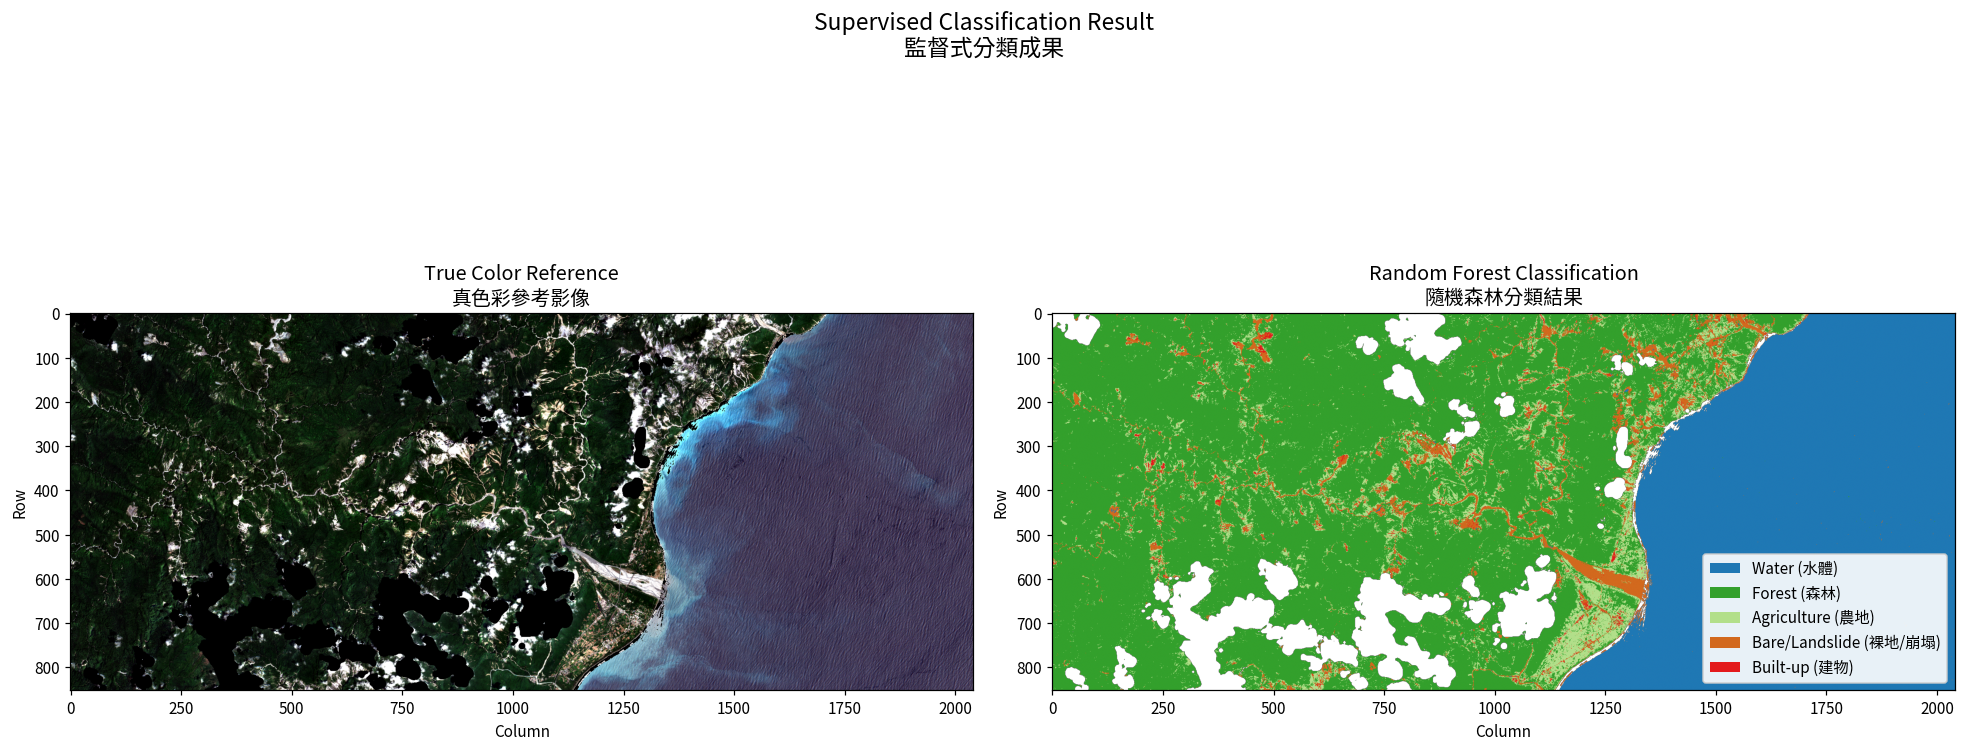

分類完成。


In [ ]:
# =============================================================================
# Task 2.4: 全影像分類 + 分類圖視覺化
# =============================================================================

# --- 分類配色設定 ---
lc_colors = [
    "#1f78b4",  # 0: Water — 藍色
    "#33a02c",  # 1: Forest — 深綠
    "#b2df8a",  # 2: Agriculture — 淺綠
    "#d2691e",  # 3: Bare/Landslide — 棕色
    "#e31a1c",  # 4: Built-up — 紅色
]
lc_cmap = mcolors.ListedColormap(lc_colors)
lc_bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
lc_norm = mcolors.BoundaryNorm(lc_bounds, lc_cmap.N)

# 1. 對所有有效像素進行分類預測
# Hint: 使用 rf.predict(pixels_valid)
print("正在對全影像進行分類預測...")
rf_labels = rf.predict(pixels_valid)  # 對 pixels_valid 進行預測

# 2. 重建分類圖（將一維結果還原為二維影像）
# Hint: 先建立全 NaN 陣列，再填入預測結果，最後 reshape
class_map_rf = np.full(pixels.shape[0], np.nan)
class_map_rf[valid_pixel_mask] = rf_labels  # 填入預測結果
class_map_rf = class_map_rf.reshape(n_rows, n_cols)  # 填入正確的行列數

# --- 視覺化 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左：真色彩
axes[0].imshow(true_color)
axes[0].set_title("True Color Reference\n真色彩參考影像", fontsize=13)

# 右：分類結果
im = axes[1].imshow(class_map_rf, cmap=lc_cmap, norm=lc_norm)
axes[1].set_title("Random Forest Classification\n隨機森林分類結果", fontsize=13)

# 圖例
legend_patches = [
    Patch(facecolor=lc_colors[i], label=f"{CLASS_NAMES[i]} ({CLASS_NAMES_ZH[i]})")
    for i in range(N_CLASSES)
]
axes[1].legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=10,
    framealpha=0.9,
    fancybox=True,
)

for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.suptitle(
    "Supervised Classification Result\n監督式分類成果", fontsize=15, y=1.02
)
plt.tight_layout()
plt.show()
print("分類完成。")

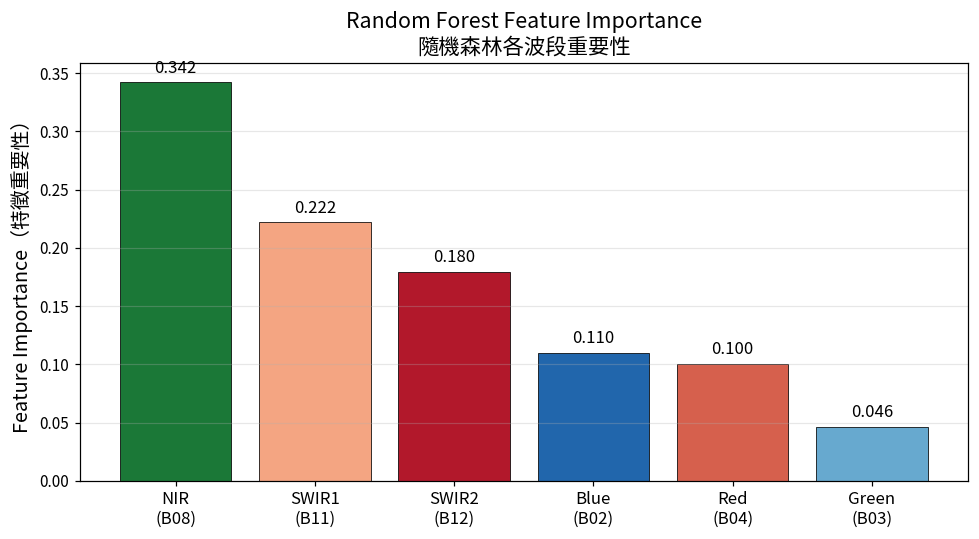


=== 特徵重要性排序 ===
  1. NIR    (B08): 0.3421
  2. SWIR1  (B11): 0.2219
  3. SWIR2  (B12): 0.1796
  4. Blue   (B02): 0.1099
  5. Red    (B04): 0.1004
  6. Green  (B03): 0.0461

分析：NIR 和 SWIR 波段通常對土地覆蓋分類最重要，
因為它們能有效區分植被、水體和裸露地表。


In [ ]:
# =============================================================================
# Task 2.5: 特徵重要性分析
# =============================================================================

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2166ac", "#67a9cf", "#d6604d", "#1b7837", "#f4a582", "#b2182b"]

bars = ax.bar(
    range(n_bands),
    importances[sorted_idx],
    color=[bar_colors[i] for i in sorted_idx],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xticks(range(n_bands))
ax.set_xticklabels(
    [f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in sorted_idx], fontsize=11
)
ax.set_ylabel("Feature Importance（特徵重要性）", fontsize=13)
ax.set_title("Random Forest Feature Importance\n隨機森林各波段重要性", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# 在柱狀圖上標數值
for bar_obj, imp in zip(bars, importances[sorted_idx]):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.005,
        f"{imp:.3f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.show()

print("\n=== 特徵重要性排序 ===")
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank + 1}. {BAND_NAMES[idx]:6s} ({BANDS[idx]}): {importances[idx]:.4f}")

print("\n分析：NIR 和 SWIR 波段通常對土地覆蓋分類最重要，")
print("因為它們能有效區分植被、水體和裸露地表。")

K-means vs Random Forest side-by-side comparison graph

正在進行 K-means 標籤重新對應...
標籤對應完成！開始繪製比較圖...


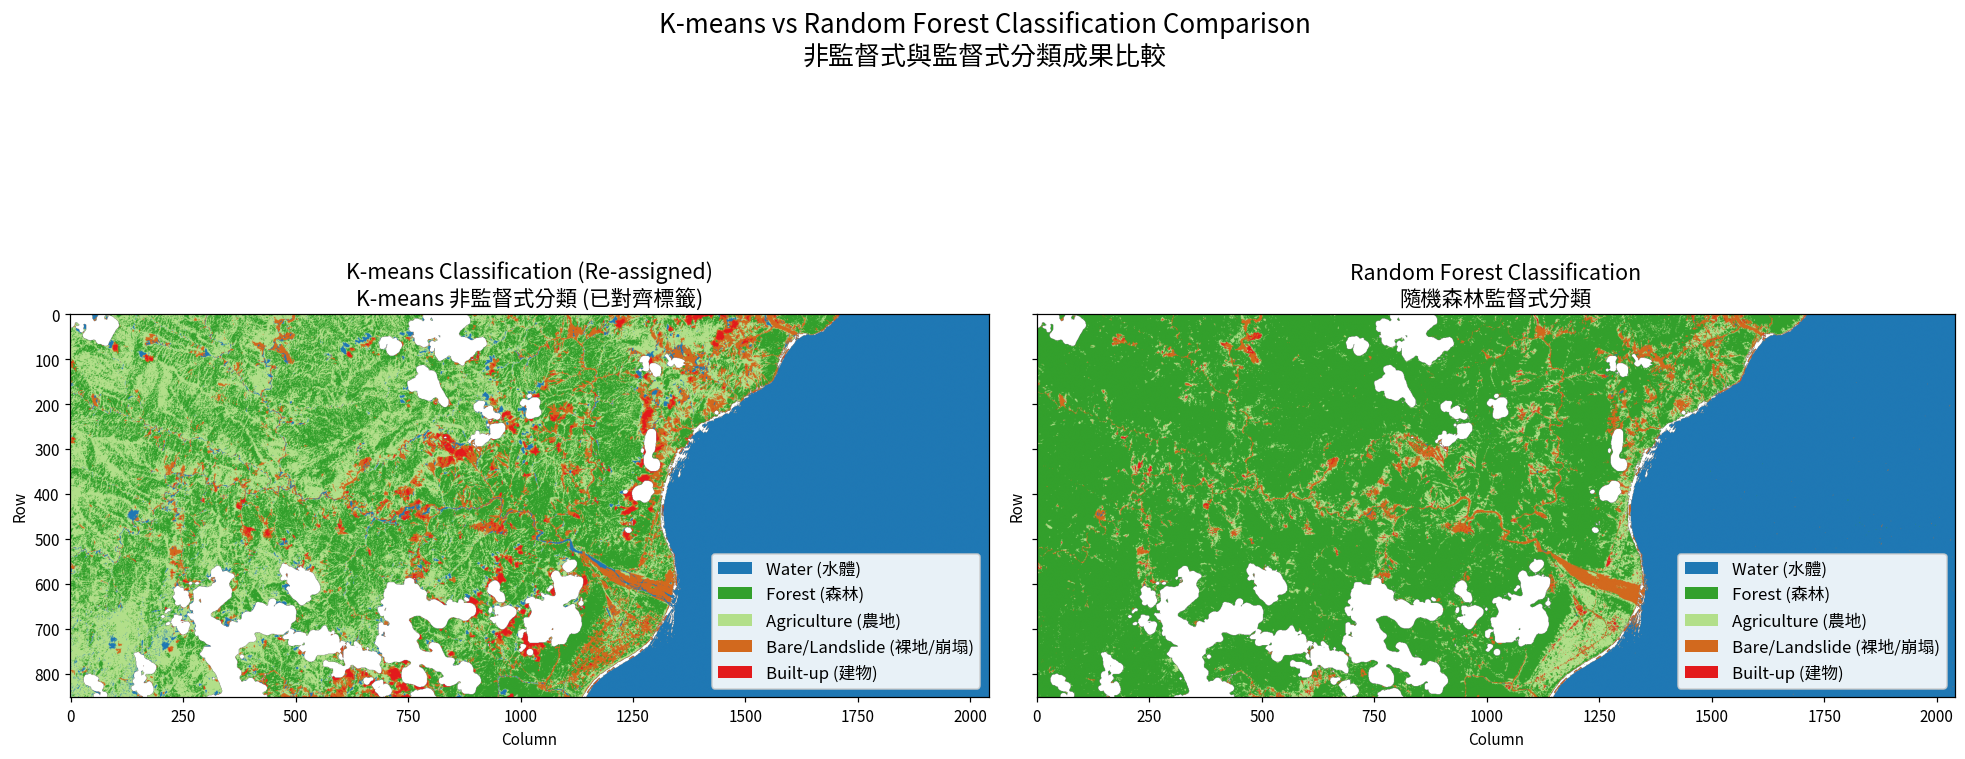

In [ ]:
# =============================================================================
# Task 2.5: K-means vs Random Forest Side-by-Side Comparison
# =============================================================================
import copy

print("正在進行 K-means 標籤重新對應...")

# 1. 建立 K-means 到 RF 類別的對應字典
# K-means 原始 ID -> RF 目標 ID
km_to_rf_mapping = {
    1: 0,  # Water
    0: 1,  # Forest
    3: 2,  # Agriculture
    2: 3,  # Bare/Landslide
    4: 4   # Built-up
}

# 2. 轉換 K-means 的結果矩陣
class_map_km_remapped = np.copy(class_map_km)
for km_val, rf_val in km_to_rf_mapping.items():
    # 將原本為 km_val 的像素，重新賦值為 rf_val
    class_map_km_remapped[class_map_km == km_val] = rf_val

print("標籤對應完成！開始繪製比較圖...")

# 3. 視覺化比較 (使用 RF 中已經定義好的 lc_cmap, lc_norm, legend_patches)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# 左圖：重新映射後的 K-means
im0 = axes[0].imshow(class_map_km_remapped, cmap=lc_cmap, norm=lc_norm)
axes[0].set_title("K-means Classification (Re-assigned)\nK-means 非監督式分類 (已對齊標籤)", fontsize=14)

# 右圖：Random Forest
im1 = axes[1].imshow(class_map_rf, cmap=lc_cmap, norm=lc_norm)
axes[1].set_title("Random Forest Classification\n隨機森林監督式分類", fontsize=14)

# 共同格式設定：加入座標軸標籤與圖例
for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.legend(
        handles=legend_patches,
        loc="lower right",
        fontsize=11,
        framealpha=0.9,
        fancybox=True,
    )

# 主標題
plt.suptitle("K-means vs Random Forest Classification Comparison\n非監督式與監督式分類成果比較", fontsize=17, y=1.02)
plt.tight_layout()
plt.show()

### Task 3: Accuracy Assessment & Independent Validation (35%)

**Goal:** Evaluate classification quality using both internal metrics (confusion matrix) and **independent reference data** from SWCB（農業部水土保持署）post-earthquake landslide inventory.

This task has two parts: **Part A** uses your own train/test split (internal validation); **Part B** compares your "Bare/Landslide" class against an official government dataset (external validation).


#### Part A: Internal Accuracy Metrics

正在計算分類精度指標...


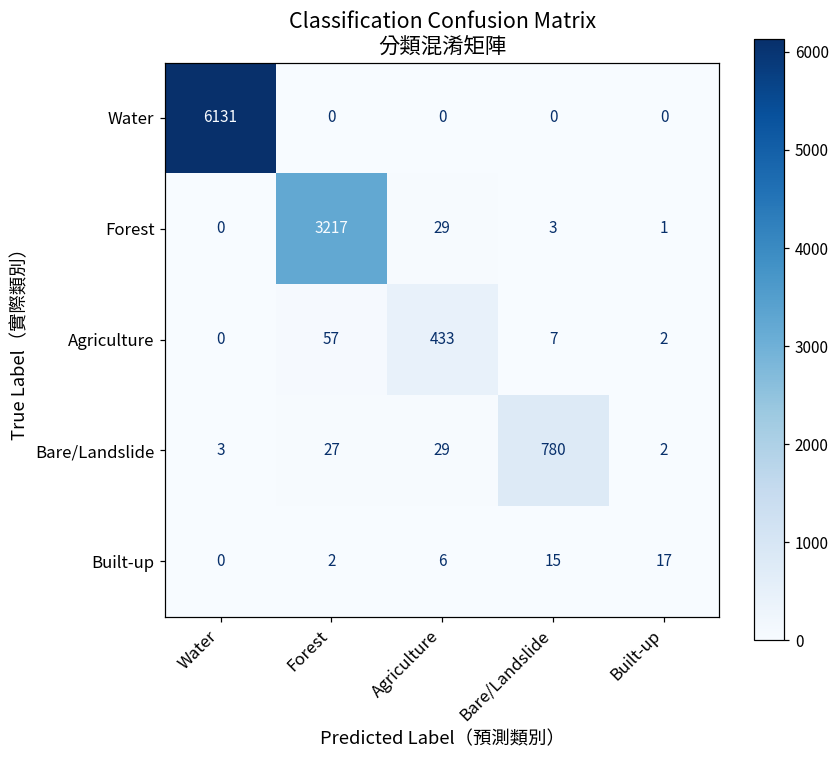


              Classification Report
                precision    recall  f1-score   support

         Water       1.00      1.00      1.00      6131
        Forest       0.97      0.99      0.98      3250
   Agriculture       0.87      0.87      0.87       499
Bare/Landslide       0.97      0.93      0.95       841
      Built-up       0.77      0.42      0.55        40

      accuracy                           0.98     10761
     macro avg       0.92      0.84      0.87     10761
  weighted avg       0.98      0.98      0.98     10761


            Additional Accuracy Metrics
Test Accuracy (OA) : 0.9830 (98.30%)
Cohen's Kappa      : 0.9704
OOB Accuracy       : 0.9823
Macro/Weighted Gap : 0.1131 (若大於 0.03 代表少數類別可能被忽略)

[判讀]: Kappa > 0.8 為 almost perfect agreement


In [ ]:
# =============================================================================
# Task 3 Part A: Internal Accuracy Metrics
# 混淆矩陣 + Classification Report + OOB/Test Accuracy
# =============================================================================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    cohen_kappa_score
)

print("正在計算分類精度指標...")

# 1. 產生測試集的預測結果 (若你前面已經算過 y_pred_test 可省略這行)
y_pred_test = rf.predict(X_te)
cm = confusion_matrix(y_te, y_pred_test)

# ── YOUR TURN ──
# 1. 繪製混淆矩陣熱力圖 (使用老師要求的 ConfusionMatrixDisplay)
fig, ax = plt.subplots(figsize=(8, 7))

# 這裡假設你的類別名稱變數是 CLASS_NAMES，若前面變數名叫 class_names 請自行替換
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title("Classification Confusion Matrix\n分類混淆矩陣", fontsize=14)
ax.set_xlabel("Predicted Label（預測類別）", fontsize=12)
ax.set_ylabel("True Label（實際類別）", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()
# ── END YOUR TURN ──

# ── YOUR TURN ──
# 2. 印出 Classification Report (作業要求重點)
print("\n" + "="*50)
print("              Classification Report")
print("="*50)
print(classification_report(y_te, y_pred_test, target_names=CLASS_NAMES))

# 3. 計算並印出 OA, Kappa 與 OOB Score
OA = accuracy_score(y_te, y_pred_test)
kappa = cohen_kappa_score(y_te, y_pred_test)

print("\n" + "="*50)
print("            Additional Accuracy Metrics")
print("="*50)
print(f"Test Accuracy (OA) : {OA:.4f} ({OA * 100:.2f}%)")
print(f"Cohen's Kappa      : {kappa:.4f}")

# 作業要求：檢查 OOB Score (前提是 Task 2 的 rf 模型有設定 oob_score=True)
if hasattr(rf, 'oob_score_'):
    print(f"OOB Accuracy       : {rf.oob_score_:.4f}")

    # 計算 Macro vs Weighted Avg F1-score 差異，幫助你寫報告討論
    report_dict = classification_report(y_te, y_pred_test, output_dict=True)
    f1_gap = abs(report_dict['macro avg']['f1-score'] - report_dict['weighted avg']['f1-score'])
    print(f"Macro/Weighted Gap : {f1_gap:.4f} (若大於 0.03 代表少數類別可能被忽略)")
else:
    print("OOB Accuracy       : Not available (請確認 Task 2 中 rf 模型有設定 oob_score=True)")

print(f"\n[判讀]: Kappa > 0.8 為 almost perfect agreement")
# ── END YOUR TURN ──

#### Part B: Independent Validation with SWCB Landslide Inventory

The file `20240802新生崩塌地.kml` contains **official post-earthquake landslide polygons** mapped by SWCB（農業部水土保持署）using high-resolution imagery. This is your **independent reference data** — it was NOT used in training.

> **Download link:** [20240802新生崩塌地.kml（Google Drive）](https://drive.google.com/file/d/17ka8y4N3IADSnJ1ymCJuzOfkutRzG-p8/view?usp=sharing) — download this file and upload it to your Colab working directory.

In [24]:
# =============================================================================
# Task 3B.1: 讀取並裁切 SWCB 崩塌地 KML 圖資
# =============================================================================
import geopandas as gpd
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, box

print("正在解析 KML 檔案...")
# 解析 KML — 擷取多邊形座標
tree = ET.parse('20240802新生崩塌地.kml')
ns = {'kml': 'http://www.opengis.net/kml/2.2'}

polygons = []
for pm in tree.getroot().findall('.//kml:Placemark', ns):
    coords_el = pm.find('.//kml:coordinates', ns)
    if coords_el is not None:
        coords = []
        for pt in coords_el.text.strip().split():
            lon, lat, *_ = pt.split(',')
            coords.append((float(lon), float(lat)))
        if len(coords) >= 3:
            polygons.append(Polygon(coords))

# 建立 GeoDataFrame
gdf_swcb = gpd.GeoDataFrame(geometry=polygons, crs='EPSG:4326')

# 裁切至研究區 BBOX
study_box = box(*TAROKO_BBOX)
gdf_clipped = gdf_swcb[gdf_swcb.intersects(study_box)].copy()

print(f"研究區內的 SWCB 崩塌地多邊形數量: {len(gdf_clipped)} 個")

正在解析 KML 檔案...
研究區內的 SWCB 崩塌地多邊形數量: 207 個


#### 將向量圖資網格化 (Rasterize)
機器學習的分類結果是網格影像 (Raster)，而 SWCB 的資料是向量多邊形 (Vector)。為了進行像素等級的空間比對，我們必須先將 SWCB 的多邊形轉換成與分類圖具備相同空間解析度與範圍的網格矩陣。

In [25]:
# =============================================================================
# Task 3B.2: 將 SWCB 向量多邊形網格化 (Rasterize) 以對齊分類圖
# =============================================================================
from rasterio.features import rasterize
from rasterio.transform import from_bounds

print("正在將向量圖資網格化...")
# 建立與分類圖一致的空間轉換矩陣 (使用先前的 n_cols, n_rows 變數)
transform = from_bounds(*TAROKO_BBOX, n_cols, n_rows)

# 網格化: 1 = SWCB 官方崩塌地, 0 = 非崩塌地
swcb_mask = rasterize(
    [(geom, 1) for geom in gdf_clipped.geometry],
    out_shape=(n_rows, n_cols),
    transform=transform,
    fill=0,
    dtype='uint8',
)
print(f"SWCB 官方崩塌地總像素數: {swcb_mask.sum():,} pixels")

正在將向量圖資網格化...
SWCB 官方崩塌地總像素數: 2,403 pixels


#### 計算空間重疊指標 (Spatial Overlap Metrics)
取出我們 Random Forest 預測結果中的「裸地/崩塌 (Bare/Landslide)」類別（類別 ID 為 3），與官方圖資計算 Recall (召回率)、Precision (精確率) 以及 IoU (交集宇集比)。

In [26]:
# =============================================================================
# Task 3B.3: 計算空間重疊指標
# =============================================================================

# 擷取 Random Forest 的崩塌地預測結果 (類別 ID = 3 代表 Bare/Landslide)
rf_landslide = (class_map_rf == 3).astype(int)

# 像素等級比對
intersection = np.sum((rf_landslide == 1) & (swcb_mask == 1))
union = np.sum((rf_landslide == 1) | (swcb_mask == 1))

# Recall: 官方標示的崩塌地中，有多少比例被模型成功偵測？
recall = intersection / swcb_mask.sum() if swcb_mask.sum() > 0 else 0
# Precision: 模型預測為崩塌地的像素中，有多少比例被官方圖資證實？
precision = intersection / rf_landslide.sum() if rf_landslide.sum() > 0 else 0
# IoU (Intersection over Union): 兩者的空間重疊程度綜合指標
iou = intersection / union if union > 0 else 0

print(f"Recall (偵測率/召回率) : {recall:.3f}")
print(f"Precision (準確率)     : {precision:.3f}")
print(f"IoU (Jaccard 交集宇集比): {iou:.3f}")

Recall (偵測率/召回率) : 0.117
Precision (準確率)     : 0.005
IoU (Jaccard 交集宇集比): 0.005


#### 重疊視覺化與誤差分析 (Overlay Visualization)
將預測結果與官方資料疊合顯示：
- **綠色 (True Positive, TP):** 模型與官方皆認定為崩塌地（吻合）
- **紅色 (False Negative, FN):** 官方標示為崩塌，但模型漏抓
- **黃色 (False Positive, FP):** 模型預測為崩塌，但官方未標示（可能多抓或誤判）

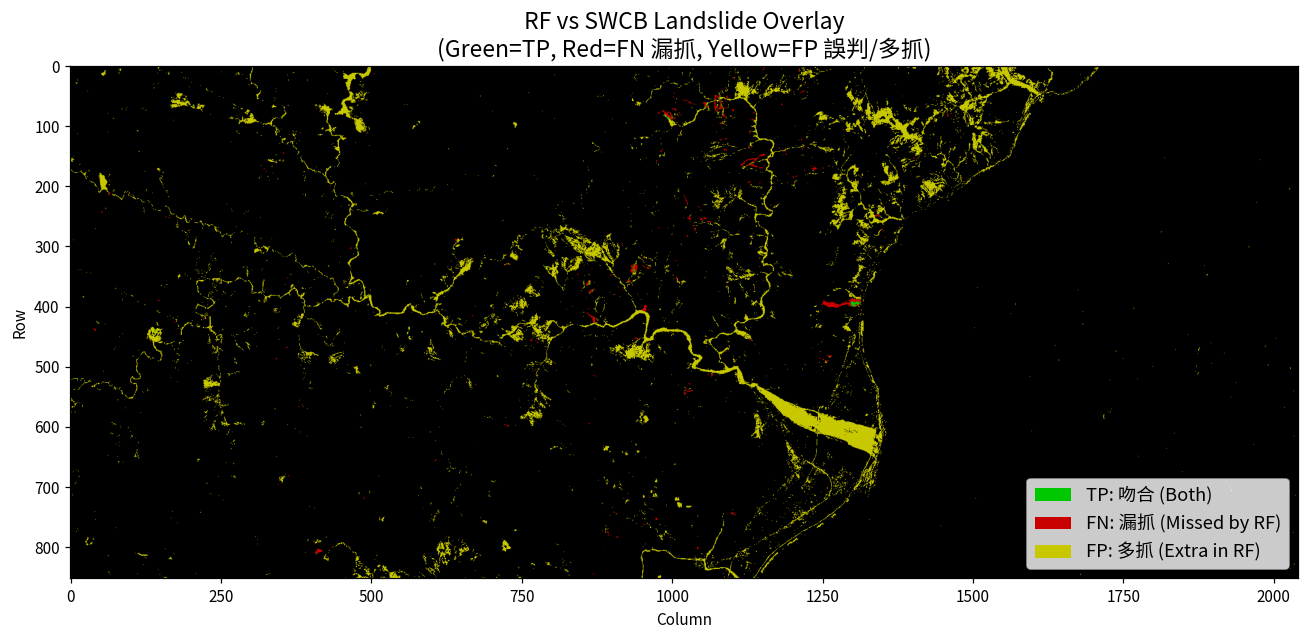

In [27]:
# =============================================================================
# Task 3B.4: 預測結果與官方圖資重疊視覺化
# =============================================================================

# 建立疊加圖: TP (綠), FN (紅), FP (黃)
overlay = np.zeros((n_rows, n_cols, 3), dtype=np.uint8)
overlay[(rf_landslide == 1) & (swcb_mask == 1)] = [0, 200, 0]    # TP: 綠色 (完美吻合)
overlay[(rf_landslide == 0) & (swcb_mask == 1)] = [200, 0, 0]    # FN: 紅色 (模型漏抓)
overlay[(rf_landslide == 1) & (swcb_mask == 0)] = [200, 200, 0]  # FP: 黃色 (模型多抓/誤判)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(overlay)
ax.set_title('RF vs SWCB Landslide Overlay\n(Green=TP, Red=FN 漏抓, Yellow=FP 誤判/多抓)', fontsize=15)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

# 加入簡易圖例說明
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#00c800', label='TP: 吻合 (Both)'),
    Patch(facecolor='#c80000', label='FN: 漏抓 (Missed by RF)'),
    Patch(facecolor='#c8c800', label='FP: 多抓 (Extra in RF)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

  **Discussion questions（必答）：**
- Why is perfect overlap (IoU = 1.0) unlikely? Consider: temporal gap（影像日期 vs SWCB 判釋日期）, spatial resolution (Sentinel-2 20m vs high-res imagery), class definition differences

  Ans:我們使用的影像是20240827的影像，但SWCB的圖資是相對即時(0802)且高解析度所建立的；這種時間落差，可能已使裸地、崩塌地範圍出現變化。除此之外，可以看到明顯我們的訓練結果多抓的情況，係因在圈選訓練資料時，我們將崩塌地/裸露地定義在相同的類型，因為他們有類似的反射光譜特徵。SWCB經過專業人員判斷，只選出實際崩塌的位置，這是靠RF方法無法區別的，進而造成極高比例的FP情況、拉低LoU。

- Where are the FN (missed) landslides concentrated? What might explain this?

  Ans:FN區域只玲心散布在山區邊坡，推測此可能為衛星拍攝時，處於背光的坡面，導致地形陰影，改變其光譜特徵進而分類到其他地表覆蓋類型。此外，如果崩塌地寬度比Sentinel-2影像還小，也可能造成混合像元，無法分辨此為崩塌地而與周遭森林混合在一起。

- How does this external validation compare to your internal test accuracy?

  Ans:內部測試配合手動框選的樣本切分，故同ROI內的像素有高空間自相關，有時容易產生過度擬和而高估分數。所以我們取得高達98.3%的OA、Kappa也達0.9704>0.8。
  然而，SWCB官方圖資是完全未參與訓練的真實資料，是以其反應模型未考慮地形、以及分類不夠細緻(或說，無法單憑光譜特徵分辨)，這種需要人工專業知識結合的缺失。以致IoU僅有0.005。

### Task 4: AI Classification Report (25%)

**Goal:** Compute area statistics and use an LLM to generate a commander's briefing, then critically evaluate the AI output.


In [ ]:
# =============================================================================
# Task 4.1: 土地覆蓋面積統計
# =============================================================================
pixel_area_m2 = 20 * 20  # Sentinel-2 解析度為 20m

class_stats = {}
for i, name in enumerate(CLASS_NAMES):
    n_pixels = np.sum(class_map_rf == i)
    area_ha = n_pixels * pixel_area_m2 / 10000  # 換算為公頃 (ha)
    class_stats[name] = {
        'pixels': int(n_pixels),
        'area_ha': round(area_ha, 1),
        'percentage': round(n_pixels / np.sum(~np.isnan(class_map_rf)) * 100, 1),
    }

import pandas as pd
stats_df = pd.DataFrame(class_stats).T
print("=== 研究區土地覆蓋統計表 ===")
print(stats_df)

# 將統計結果轉為文字，準備提供給 AI
stats_text = stats_df.to_string()

=== 研究區土地覆蓋統計表 ===
                  pixels  area_ha  percentage
Water           555810.0  22232.4        34.9
Forest          873905.0  34956.2        54.8
Agriculture     102844.0   4113.8         6.5
Bare/Landslide   54364.0   2174.6         3.4
Built-up          6900.0    276.0         0.4


### AI 生成災害分析簡報
請將產出的數據填入下方的 Prompt 中，並執行以獲得 AI 生成的中文分析報告。

In [28]:
# =============================================================================
# Task 4.2: 呼叫 AI 生成報告 (以文字範例展示，需自行填入計算出的 IoU)
# =============================================================================

# 請填入你剛剛 Task 3B 算出的 IoU 數值
final_iou = iou

report_prompt = f"""
你是花蓮縣災害應變中心的 GIS 分析師。根據以下數據撰寫一份 300-500 字的「災後土地覆蓋分析報告」。

研究區：秀林鄉 / 太魯閣周邊
災害事件：2024 年 4 月 3 日花蓮地震
分類方法：Random Forest (Overall accuracy: {OA:.1%}, SWCB landslide IoU: {final_iou:.3f})

各類別面積統計數據：
{stats_text}

報告需求：
1. 災後土地覆蓋概況描述。
2. 崩塌/裸地的空間分布與面積估算。
3. 與官方 SWCB 圖資的比對結果說明（基於 IoU 數值）。
4. 針對後續避難或交通恢復的具體建議。
"""

print("--- 建議生成的報告 Prompt 如下，可貼至 ChatGPT 或 Gemini ---")
print(report_prompt)

--- 建議生成的報告 Prompt 如下，可貼至 ChatGPT 或 Gemini ---

你是花蓮縣災害應變中心的 GIS 分析師。根據以下數據撰寫一份 300-500 字的「災後土地覆蓋分析報告」。

研究區：秀林鄉 / 太魯閣周邊
災害事件：2024 年 4 月 3 日花蓮地震
分類方法：Random Forest (Overall accuracy: 98.3%, SWCB landslide IoU: 0.005)

各類別面積統計數據：
                  pixels  area_ha  percentage
Water           555810.0  22232.4        34.9
Forest          873905.0  34956.2        54.8
Agriculture     102844.0   4113.8         6.5
Bare/Landslide   54364.0   2174.6         3.4
Built-up          6900.0    276.0         0.4

報告需求：
1. 災後土地覆蓋概況描述。
2. 崩塌/裸地的空間分布與面積估算。
3. 與官方 SWCB 圖資的比對結果說明（基於 IoU 數值）。
4. 針對後續避難或交通恢復的具體建議。



###LLM-generated report
1. 災後土地覆蓋概況
本次針對 2024 年 4 月 3 日花蓮地震後，秀林鄉與太魯閣周邊區域進行 Sentinel-2 衛星影像遙測分類。結果顯示，研究區以自然地景為主：森林面積最廣，達 34,956.2 公頃（佔 54.8%），其次為涵蓋近海的太平洋水體 22,232.4 公頃（34.9%）。受限於山高谷深的地形，人類活動密集的農業區（4,113.8 公頃，6.5%）與建物/都市（276.0 公頃，0.4%）佔比較小。本次隨機森林（Random Forest）模型之內部整體分類準確度（OA）高達 98.3%。

2. 崩塌/裸地面積估計與空間分布
經模型分類，災後「裸地/崩塌」的總面積估算為 2,174.6 公頃（佔 3.4%）。這些區域在光譜上呈現缺乏植被覆蓋的高反射率特徵，在空間分布上，推測主要集中於地震引發的陡峭坡面崩塌、岩石裸露區，以及立霧溪等流域的枯水期河床兩側。

3. 與官方 SWCB 圖資的比對與不確定性說明
將本分類結果與農業部水保署（SWCB）的官方崩塌圖資進行獨立驗證，交集宇集比（IoU）僅為 0.005。此顯著落差主要源於「定義差異」與「解析度限制」。隨機森林模型僅依賴光譜反射率，因此會將「正常河床乾枯地」或「一般裸露空地」皆誤判為崩塌（產生大量 False Positive）；相對地，SWCB 圖資是由專家綜合地形脈絡精確描繪的真正災害區。此外，影像 20 公尺的中解析度與拍攝時間差，也導致機器難以完美吻合官方的高精度邊界。

4. 避難與交通恢復建議
鑑於 2,174.6 公頃的潛在裸地/崩塌區可能對救災造成威脅，建議將此分類圖與「既有道路網向量圖資」疊合，盤點出與棕色裸地區塊相交的高風險路段（如蘇花公路沿線），以優先進行無人機空拍勘查與落石清除。同時，可利用現有安全的建物區（0.4%）與平坦森林區，輔以 DEM（數值地形模型）排除陡坡，重新評估並選定遠離潛在崩塌區的安全避難所位置。

###Critical evaluation of the LLM report
經過檢核，AI 報告中引用的各類別面積數據與百分比（如森林 34,956.2 ha、裸地 2,174.6 ha 等）沒有錯誤，未出現數值幻覺（Hallucination）。在「不確定性說明」方面，AI 提出的解釋非常合理，精準點出了 IoU 僅 0.005 的根本原因來自於RF只看光譜特徵、官方判釋有專業人員空間/地貌認知的差異。這些結論和人工判讀相同，不過在避難與交通恢復建議，AI把大量錯判的潛在崩塌區都認為有致災可能的威脅，這同樣反映AI缺乏真實地形、空間、影像的知識，只能從統計地圖解讀；如果配合人工判斷，應該會減少許多需要再進行比對的範圍，雖然在防災上應秉持寧可錯殺一百不可錯放一隻的精神，但也應避免耗費大量資源。